The SVM exercise asks you to generate a random dataset following a quadratic distribution and classify it using SVM.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [2]:
np.random.seed(42)

n = 500

x1 = np.random.uniform(-5, 5, n)
x2 = np.random.uniform(-2, 25, n)

y = (x2 > x1**2).astype(int)

X = np.column_stack((x1, x2))

print("Dataset shape:", X.shape)
print("Target shape:", y.shape)

Dataset shape: (500, 2)
Target shape: (500,)


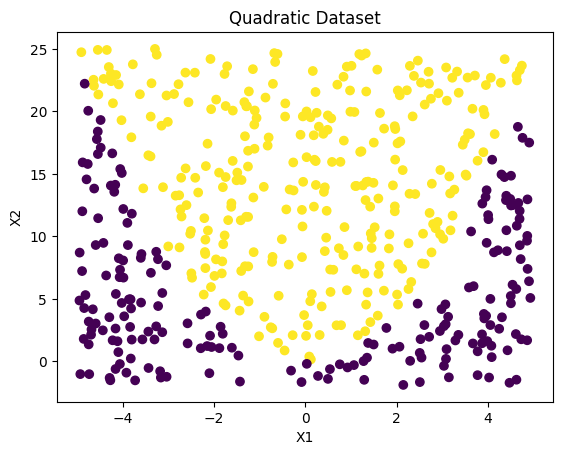

In [3]:
plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y
)

plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Quadratic Dataset")

plt.show()

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 400
Testing samples: 100


In [5]:
model = SVC(
    kernel='rbf',
    random_state=42
)

model.fit(X_train, y_train)

SVC(random_state=42)

In [6]:
y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred)

Predictions:
[1 1 0 0 0 1 0 1 1 1 1 0 1 1 0 0 0 1 1 0 1 1 1 0 0 1 0 1 1 0 0 1 0 1 1 0 0
 1 1 0 1 1 1 1 0 1 1 0 1 1 0 0 1 1 1 0 1 1 0 1 1 0 1 0 0 0 1 0 1 1 0 1 1 0
 1 1 1 0 1 1 0 1 0 0 0 0 1 1 0 1 1 1 1 0 1 1 0 1 0 0]


In [7]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

Accuracy: 0.93
Accuracy Percentage: 93.0 %


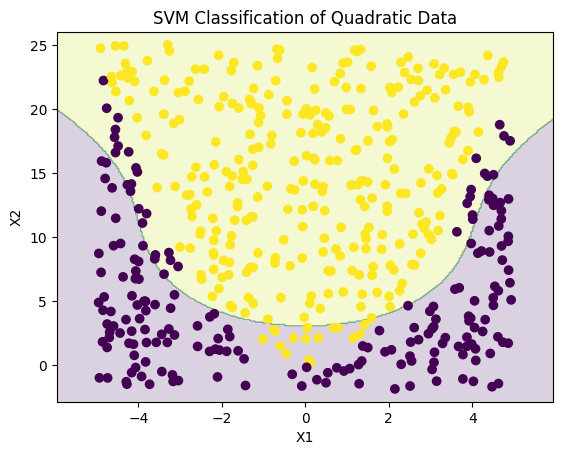

In [8]:
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]

Z = model.predict(grid)

Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.2)

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y
)

plt.xlabel("X1")
plt.ylabel("X2")
plt.title("SVM Classification of Quadratic Data")

plt.show()

Conclusion: An SVM classifier with an RBF kernel was successfully applied to a quadratic-distribution dataset. The model was trained, tested and evaluated using classification accuracy.